In [1]:
import numpy as np
import cv2
import tensorflow as tf
import rasterio

class SARImageReverter:
    """
    Reverts SAR preprocessing steps:
    - [0,1] normalization → dB
    - dB → linear Sigma0
    NOTE:
    - Refined Lee filtering and resizing are irreversible
    """

    def __init__(self, min_db=-30, max_db=5):
        self.min_db = min_db
        self.max_db = max_db

    def denormalize_from_range(self, image):
        """Revert normalization from [0,1] back to dB scale."""
        return image * (self.max_db - self.min_db) + self.min_db

    def convert_from_db(self, image_db):
        """Convert dB back to linear Sigma0 scale."""
        return np.power(10.0, image_db / 10.0)

    def revert_pipeline(self, image):
        """
        Full reversion pipeline:
        normalized → dB → linear Sigma0
        """
        # Step 1: [0,1] → dB
        image_db = self.denormalize_from_range(image)

        # Step 2: dB → linear
        image_linear = self.convert_from_db(image_db)

        return image_linear

In [2]:
IMG_SIZE = (512, 512)

def load_sar_tiff(path):

    def _read_image(p):
        # Convert TensorFlow input to Python string
        if isinstance(p, bytes):
            path_str = p.decode("utf-8")
        elif isinstance(p, np.ndarray):
            val = p.item()
            path_str = val.decode("utf-8") if isinstance(val, bytes) else str(val)
        else:
            path_str = str(p)

        with rasterio.open(path_str) as src:
            vv = src.read(1).astype(np.float32)
            vh = src.read(2).astype(np.float32)

        # ASSUMES vv/vh ARE IN dB
        vv = np.clip(vv, -35, 5)
        vh = np.clip(vh, -40, 0)

        vv = (vv + 35) / 40
        vh = (vh + 40) / 40

        img = np.stack([vv, vh], axis=-1)

        # Resize in NumPy/TensorFlow (still OK)
        img = tf.image.resize(img, IMG_SIZE).numpy()

        return img

    img = tf.numpy_function(
        _read_image,
        [path],
        tf.float32
    )

    # NOW this is valid
    img.set_shape([512, 512, 2])

    return img

In [3]:
reverter = SARImageReverter(min_db=-30, max_db=5)

img = load_sar_tiff("/Volumes/Windows8_OS/Dataset/Dataset-OG/Test/Images/Lookalike/00002.tif")

reverted_sigma0 = reverter.revert_pipeline(img)

print(reverted_sigma0.shape)
print(reverted_sigma0.min(), reverted_sigma0.max())

I0000 00:00:1768761400.111354 4805081 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1768761400.112056 4805081 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


(512, 512, 2)
0.00121877 3.1622777


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def show_sigma0_db_for_display(reverted_sigma0):
    eps = 1e-10
    sigma0_db = 10 * np.log10(np.maximum(reverted_sigma0, eps))

    vv_db = sigma0_db[..., 0]
    vh_db = sigma0_db[..., 1]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(vv_db, cmap="gray", vmin=-30, vmax=5)
    axs[0].set_title("VV Sigma0 (dB)")
    axs[0].axis("off")

    axs[1].imshow(vh_db, cmap="gray", vmin=-35, vmax=0)
    axs[1].set_title("VH Sigma0 (dB)")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()


In [5]:
import matplotlib.pyplot as plt
import numpy as np

def show_reverted_sigma0(reverted_sigma0):
    """
    reverted_sigma0: (H, W, 2) or (H, W)
    """

    if reverted_sigma0.ndim == 3 and reverted_sigma0.shape[-1] == 2:
        vv = reverted_sigma0[..., 0]
        vh = reverted_sigma0[..., 1]

        fig, axs = plt.subplots(1, 2, figsize=(12, 5))

        im0 = axs[0].imshow(vv, cmap="gray")
        axs[0].set_title("VV Sigma0 (linear)")
        axs[0].axis("off")
        plt.colorbar(im0, ax=axs[0], fraction=0.046)

        im1 = axs[1].imshow(vh, cmap="gray")
        axs[1].set_title("VH Sigma0 (linear)")
        axs[1].axis("off")
        plt.colorbar(im1, ax=axs[1], fraction=0.046)

        plt.tight_layout()
        plt.show()

    else:
        plt.figure(figsize=(6, 6))
        im = plt.imshow(reverted_sigma0, cmap="gray")
        plt.title("Sigma0 (linear)")
        plt.axis("off")
        plt.colorbar(im, fraction=0.046)
        plt.show()


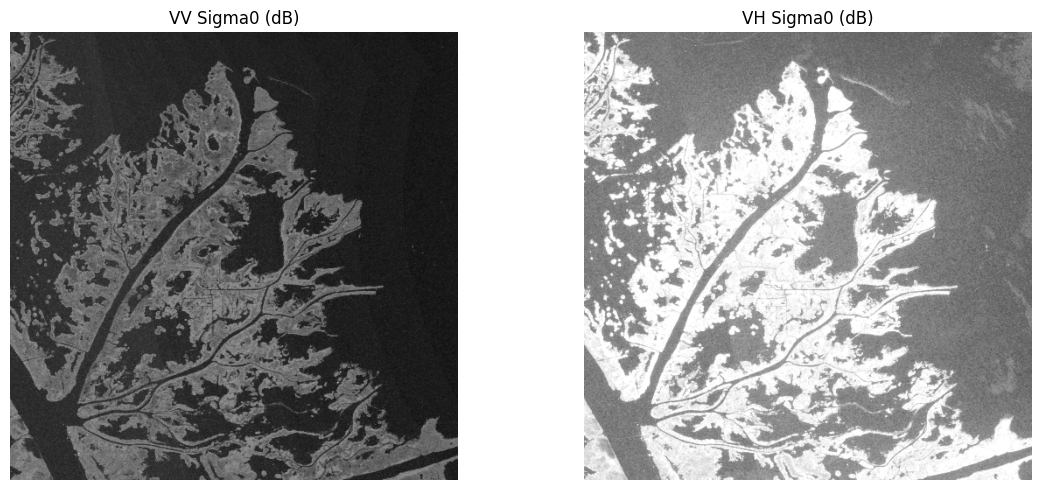

In [6]:
show_sigma0_db_for_display(reverted_sigma0)

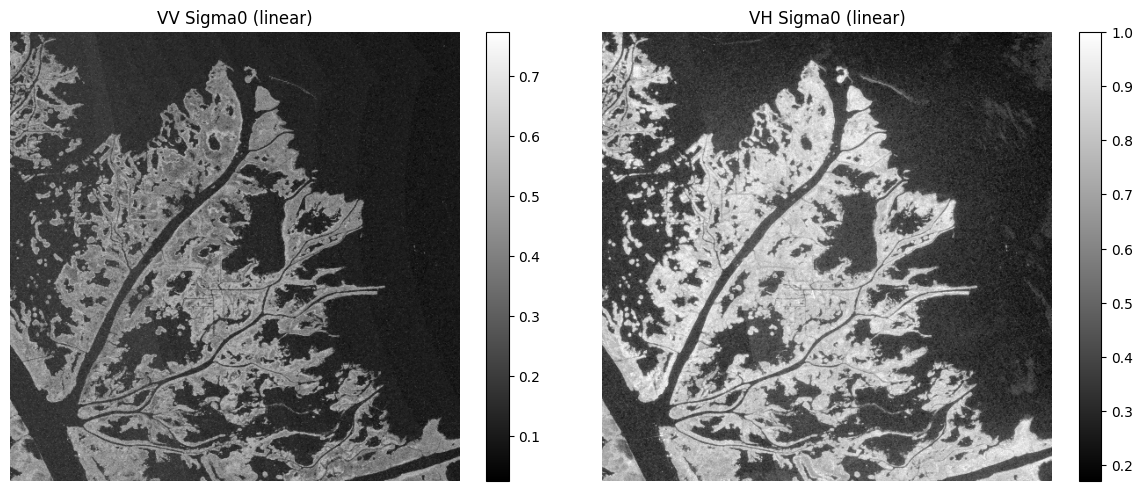

In [7]:
img_comb = combine(img)
show_reverted_sigma0(img)

In [8]:
def add_sar_speckle(linear_sigma0, looks=4):
    """
    Add multiplicative SAR speckle noise using Gamma distribution.
    looks: number of looks (Sentinel-1 ~ 4–5)
    """
    speckle = np.random.gamma(
        shape=looks,
        scale=1.0 / looks,
        size=linear_sigma0.shape
    )
    return linear_sigma0 * speckle

In [9]:
def linear_to_db(img):
    return 10 * np.log10(np.maximum(img, 1e-10))

In [10]:
def mild_smoothing(db_img, ksize=3):
    if db_img.ndim == 3:
        out = np.zeros_like(db_img)
        for c in range(db_img.shape[-1]):
            out[..., c] = cv2.GaussianBlur(db_img[..., c], (ksize, ksize), 0)
        return out
    return cv2.GaussianBlur(db_img, (ksize, ksize), 0)

In [11]:
def show_sigma0_db(db_img):
    vv = db_img[..., 0]
    vh = db_img[..., 1]

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].imshow(vv, cmap="gray", vmin=-30, vmax=5)
    axs[0].set_title("VV Sigma0 (dB)")
    axs[0].axis("off")

    axs[1].imshow(vh, cmap="gray", vmin=-35, vmax=0)
    axs[1].set_title("VH Sigma0 (dB)")
    axs[1].axis("off")

    plt.tight_layout()
    plt.show()

In [12]:
import matplotlib.pyplot as plt

def show_combined_sigma0_db(db_img):
    plt.figure(figsize=(6, 6))
    plt.imshow(db_img, cmap="gray", vmin=-30, vmax=5)
    plt.title("Combined Sigma0 (dB)")
    plt.axis("off")
    plt.colorbar(label="dB")
    plt.show()

In [13]:
import numpy as np

def combine_difference_safe(db_img):
    """
    Combines VV and VH ONLY if both exist.
    If already combined, returns input unchanged.
    """
    if db_img.ndim == 3 and db_img.shape[-1] == 2:
        vv = db_img[..., 0]
        vh = db_img[..., 1]
        return vv - vh
    elif db_img.ndim == 2:
        # Already combined
        return db_img
    else:
        raise ValueError(f"Unsupported shape: {db_img.shape}")


In [15]:
reverted_sigma0 = reverter.revert_pipeline(img)
sigma0_speckled = add_sar_speckle(reverted_sigma0, looks=4)
sigma0_db = linear_to_db(sigma0_speckled)
sigma0_db_smoothed = mild_smoothing(sigma0_db, ksize=3)
sigma0_db_smoothed = combine_difference_safe(sigma0_db_smoothed)

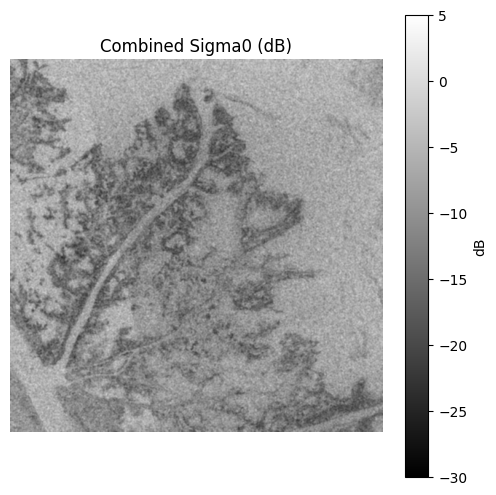

In [16]:
show_combined_sigma0_db(sigma0_db_smoothed)

In [17]:
print(type(sigma0_db_smoothed))
print(sigma0_db_smoothed.shape)

<class 'numpy.ndarray'>
(512, 512)


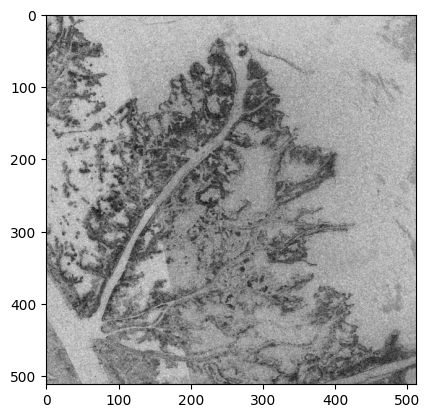

In [18]:
img = combine_difference_safe(img)
plt.imshow(img, cmap="gray")